In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve,classification_report
)

In [27]:
df = pd.read_csv(r"C:\Users\karun\OneDrive\Documents\proxymodel\data\proxy_training_data.csv")
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   time_diff_minutes           120 non-null    float64
 1   distance_km                 119 non-null    float64
 2   scan_day_of_week            119 non-null    float64
 3   scan_hour_of day            119 non-null    float64
 4   is_first_scan               119 non-null    float64
 5   historical_attendance_rate  119 non-null    float64
 6   last_attendance_streak      119 non-null    float64
 7   is_proxy                    119 non-null    float64
dtypes: float64(8)
memory usage: 7.6 KB


,time_diff_minutes,distance_km,scan_day_of_week,scan_hour_of day,is_first_scan,historical_attendance_rate,last_attendance_streak,is_proxy
0,4.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.1,0.08,2.0,11.0,0.0,0.95,16.0,0.0
2,7.5,0.21,3.0,10.0,0.0,0.88,8.0,0.0
3,2.8,0.12,3.0,11.0,0.0,0.99,25.0,0.0
4,5.0,0.10,4.0,14.0,0.0,0.91,12.0,0.0


In [28]:
df.isnull().sum()


time_diff_minutes             0
distance_km                   1
scan_day_of_week              1
scan_hour_of day              1
is_first_scan                 1
historical_attendance_rate    1
last_attendance_streak        1
is_proxy                      1
dtype: int64

<Axes: xlabel='is_proxy', ylabel='count'>

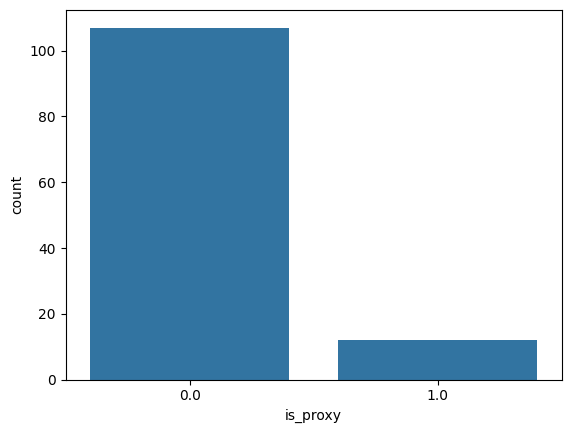

In [29]:
 df=df.dropna()
 df.isnull().sum()
 sns.countplot(x='is_proxy', data=df)


In [30]:
X = df[['time_diff_minutes','distance_km']]
y = df['is_proxy']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)


In [40]:
iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_train)
y_pred_iso = iso.predict(X_test)
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

print("Isolation Forest:\n", classification_report(y_test, y_pred_iso))

Isolation Forest:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        21
         1.0       1.00      1.00      1.00         3

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



=== Isolation Forest Performance ===
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC AUC: 1.0

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        21
         1.0       1.00      1.00      1.00         3

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



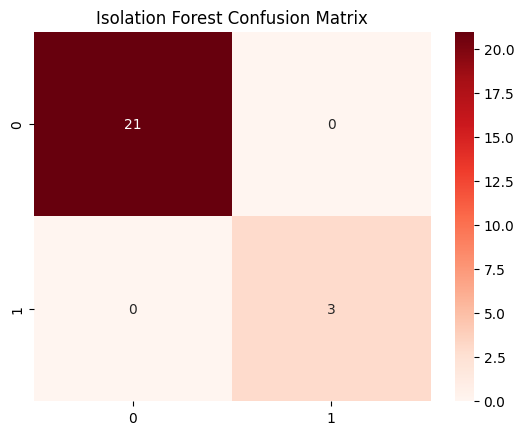

In [42]:
y_pred_iso = [1 if x == -1 else 0 for x in iso.predict(X_test)]

print("=== Isolation Forest Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_iso))
print("Precision:", precision_score(y_test, y_pred_iso))
print("Recall:", recall_score(y_test, y_pred_iso))
print("F1 Score:", f1_score(y_test, y_pred_iso))
print("ROC AUC:", roc_auc_score(y_test, y_pred_iso))
print("\nClassification Report:\n", classification_report(y_test, y_pred_iso))

cm = confusion_matrix(y_test, y_pred_iso)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("Isolation Forest Confusion Matrix")
plt.show()

In [ ]:

new_data = pd.DataFrame({
    'time_diff_minutes': [3.1],
    'distance_km': [0.08]
})

prediction = iso.predict(new_data)
print(prediction)
#the output is in -1 or 1 (anomaly=-1 ,normal=1)


[1]


In [18]:
x_rest=df[['scan_day_of_week','scan_hour_of day','is_first_scan','historical_attendance_rate','last_attendance_streak']]
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(x_rest, y)


In [19]:
X_train, X_test, y_train, y_test = train_test_split( X_res, y_res, test_size=0.20, random_state=42, stratify=y_res)


In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.metrics import classification_report

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression:\n", classification_report(y_test, y_pred_log))

Logistic Regression:
               precision    recall  f1-score   support

         0.0       0.78      0.95      0.86        22
         1.0       0.94      0.71      0.81        21

    accuracy                           0.84        43
   macro avg       0.86      0.83      0.83        43
weighted avg       0.86      0.84      0.83        43



In [22]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest:\n", classification_report(y_test, y_pred_rf))

Random Forest:
               precision    recall  f1-score   support

         0.0       0.96      1.00      0.98        22
         1.0       1.00      0.95      0.98        21

    accuracy                           0.98        43
   macro avg       0.98      0.98      0.98        43
weighted avg       0.98      0.98      0.98        43



In [ ]:
iso2 = IsolationForest(contamination=0.1, random_state=42)
iso2.fit(X_train_scaled)
y_pred_iso = iso2.predict(X_test_scaled)
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

print("Isolation Forest:\n", classification_report(y_test, y_pred_iso))

Isolation Forest:
               precision    recall  f1-score   support

         0.0       0.63      1.00      0.77        22
         1.0       1.00      0.38      0.55        21

    accuracy                           0.70        43
   macro avg       0.81      0.69      0.66        43
weighted avg       0.81      0.70      0.66        43



=== Logistic Regression Performance ===
Accuracy: 0.8372093023255814
Precision: 0.9375
Recall: 0.7142857142857143
F1 Score: 0.8108108108108109
ROC AUC: 0.8344155844155845

Classification Report:
               precision    recall  f1-score   support

         0.0       0.78      0.95      0.86        22
         1.0       0.94      0.71      0.81        21

    accuracy                           0.84        43
   macro avg       0.86      0.83      0.83        43
weighted avg       0.86      0.84      0.83        43



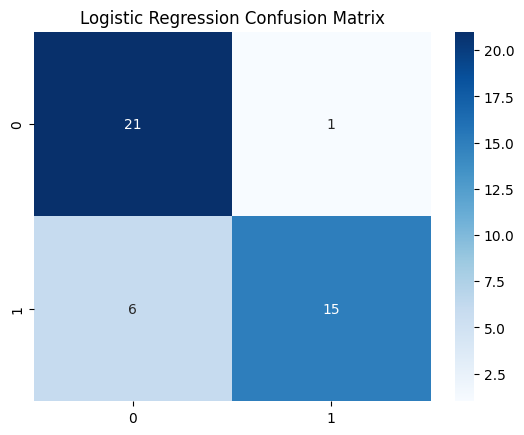

In [24]:
print("=== Logistic Regression Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()


=== Random Forest Performance ===
Accuracy: 0.9767441860465116
Precision: 1.0
Recall: 0.9523809523809523
F1 Score: 0.975609756097561
ROC AUC: 0.9761904761904762

Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      1.00      0.98        22
         1.0       1.00      0.95      0.98        21

    accuracy                           0.98        43
   macro avg       0.98      0.98      0.98        43
weighted avg       0.98      0.98      0.98        43



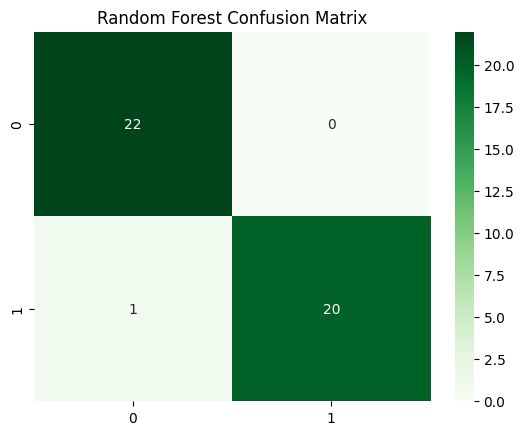

In [25]:
print("=== Random Forest Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.show()


=== Isolation Forest Performance ===
Accuracy: 0.6976744186046512
Precision: 1.0
Recall: 0.38095238095238093
F1 Score: 0.5517241379310345
ROC AUC: 0.6904761904761905

Classification Report:
               precision    recall  f1-score   support

         0.0       0.63      1.00      0.77        22
         1.0       1.00      0.38      0.55        21

    accuracy                           0.70        43
   macro avg       0.81      0.69      0.66        43
weighted avg       0.81      0.70      0.66        43



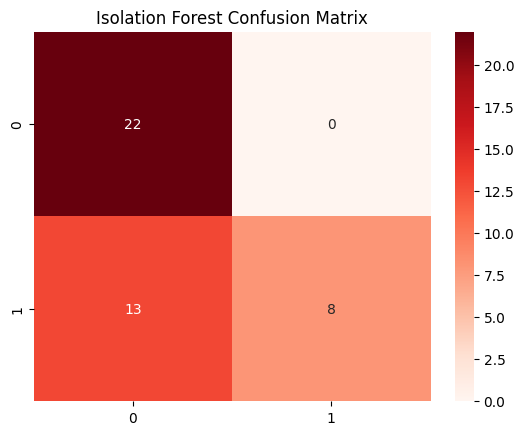

In [ ]:
# Convert -1 → 1 (proxy), 1 → 0 (genuine)
y_pred_iso = [1 if x == -1 else 0 for x in iso2.predict(X_test_scaled)]

print("=== Isolation Forest Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_iso))
print("Precision:", precision_score(y_test, y_pred_iso))
print("Recall:", recall_score(y_test, y_pred_iso))
print("F1 Score:", f1_score(y_test, y_pred_iso))
print("ROC AUC:", roc_auc_score(y_test, y_pred_iso))
print("\nClassification Report:\n", classification_report(y_test, y_pred_iso))

cm = confusion_matrix(y_test, y_pred_iso)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("Isolation Forest Confusion Matrix")
plt.show()
